In [1]:
from herbie import Herbie
import matplotlib.pyplot as plt
from cartopy import feature as cfeature
import xarray as xr
from herbie.toolbox import EasyMap, pc
import os
import numpy as np
import torch
import torch.nn as nn
from diffusers import UNet2DConditionModel, DDPMScheduler
from torch.utils.data import Dataset, DataLoader, random_split
from datetime import datetime

c:\Users\joebe\anaconda3\envs\storm-surge\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Load Dataset

In [3]:
ds_input = xr.open_dataset(f'./data/parametric_inputs/AL032016/patch1/06-06-2016-12-00_data', decode_timedelta=True, engine='netcdf4')
ds_output = xr.open_dataset(f'./data/filtered_HRRR/AL032016/patch1/06-06-2016-12-00_data', decode_timedelta=True, engine='netcdf4')
ds_output

<xarray.Dataset> Size: 772kB
Dimensions:              (y: 166, x: 166)
Coordinates:
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    heightAboveGround    float64 8B ...
    latitude             (y, x) float64 220kB ...
    longitude            (y, x) float64 220kB ...
    valid_time           datetime64[ns] 8B ...
    gribfile_projection  float64 8B ...
    surface              float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                  (y, x) float32 110kB ...
    v10                  (y, x) float32 110kB ...
    sp                   (y, x) float32 110kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   hrrr
    product:                 prs
    description:             High-Resolution Rapid Refresh - CONUS
    remote_grib:             https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr....
    local_grib:              c:\Users\joebe\Downloads\GitHub\StormSurgeAI\Sto...
    search:                  :UGRD:10 m

In [4]:
ds_input

<xarray.Dataset> Size: 2MB
Dimensions:              (y: 166, x: 166)
Coordinates:
    time                 datetime64[ns] 8B ...
    lon                  (y, x) float64 220kB ...
    lat                  (y, x) float64 220kB ...
    step                 timedelta64[ns] 8B ...
    heightAboveGround    float64 8B ...
    valid_time           datetime64[ns] 8B ...
    gribfile_projection  float64 8B ...
    surface              float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    dist_cent            (y, x) float64 220kB ...
    pressure             (y, x) float64 220kB ...
    windspeed            (y, x) float64 220kB ...
    wind_u               (y, x) float64 220kB ...
    wind_v               (y, x) float64 220kB ...
    stress_u             (y, x) float64 220kB ...
    stress_v             (y, x) float64 220kB ...
Attributes:
    tc_model:      Holland1980
    tc_B_model:    vickery00
    inflow_model:  nws
    inflow_angle:  0
    bg_model:      constant
    bg_alpha:      0.55
    bg_beta:       20
    cd_model:      garratt77
    cd_min:        0
    cd_max:        0.003

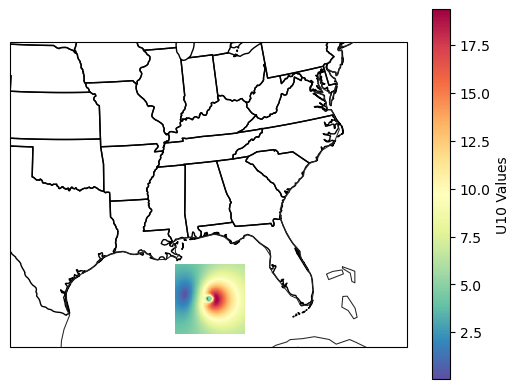

In [5]:
ax = EasyMap(crs=ds_output.herbie.crs).ax

c = ax.pcolormesh(
    ds_input.lon,
    ds_input.lat,
    ds_input.windspeed,
    cmap="Spectral_r",
    transform=pc,
)

ax.set_extent([-100, -75, 25, 40], crs=pc)
ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.adjust_extent()


fig = plt.gcf()  
fig.colorbar(c, ax=ax, orientation='vertical', label='U10 Values')

plt.show()

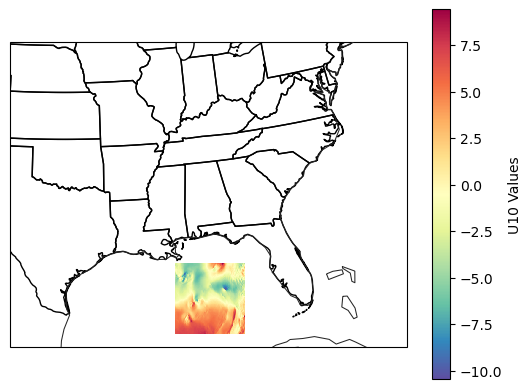

In [6]:
ax = EasyMap(crs=ds_output.herbie.crs).ax

c = ax.pcolormesh(
    ds_output.longitude,
    ds_output.latitude,
    ds_output.u10,
    cmap="Spectral_r",
    transform=pc,
)

ax.set_extent([-100, -75, 25, 40], crs=pc)
ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.adjust_extent()


fig = plt.gcf()  
fig.colorbar(c, ax=ax, orientation='vertical', label='U10 Values')

plt.show()

In [7]:
# Loop through each hurricane folder
patch_count = 0
total_size = 0
file_count = 0
hurricane_count = 0
patch_size = 166
for hurricane in os.listdir('./data/parametric_inputs'):
    hurricane_path = os.path.join('./data/parametric_inputs', hurricane)
    if os.path.isdir(hurricane_path):
        hurricane_count += 1
        for patch in os.listdir(hurricane_path):
            patch_path = os.path.join(hurricane_path, patch)
            if os.path.isdir(patch_path):
                patch_count += 1
                for file in os.listdir(patch_path):
                    fp = os.path.join(patch_path, file)
                    if not os.path.islink(fp):
                        file_path = os.path.join(hurricane_path, patch + '/' + file)
                        file_count+=1
                        total_size += os.path.getsize(file_path)

print('500 km - No Partial Patches')
print(f'  Size: {total_size/1e+9} GB')
print(f'  File Count: {file_count}')
print(f'  Patch Count: {patch_count}')
print(f'  Average Number of Patches per Hurricane: {patch_count/hurricane_count}')
print(f'  Average Number of Files per Patch: {file_count/patch_count}')
print(f'  Average File Size: {(total_size/file_count)/1e+3} KB')
print(f'  Average Patch Size: {(total_size/patch_count)/1e+6} MB')
print(f'  Pixels: {patch_size}x{patch_size} --> {patch_size*patch_size} pixels')

500 km - No Partial Patches
  Size: 8.117029033 GB
  File Count: 4037
  Patch Count: 602
  Average Number of Patches per Hurricane: 11.358490566037736
  Average Number of Files per Patch: 6.705980066445183
  Average File Size: 2010.6586655932622 KB
  Average Patch Size: 13.483436931893687 MB
  Pixels: 166x166 --> 27556 pixels


# Hyperparameters

In [8]:
lr = 1e-4
batch_size = 32
num_epochs = 25
patience = 10

# Data Loading

In [9]:
h80_data = []
hrrr_data = []

for hurricane in os.listdir('./data/parametric_inputs'):
    hurricane_path = './data/parametric_inputs/'+ hurricane
    if os.path.isdir(hurricane_path): 
        for patch in os.listdir(hurricane_path):
            patch_path = hurricane_path + '/' + patch
            if os.path.isdir(patch_path):
                for file in os.listdir(patch_path):
                    fp = os.path.join(patch_path, file)
                    if not os.path.islink(fp):
                        input_file = patch_path + '/' + file
                        output_file = input_file.replace('parametric_inputs', 'filtered_hrrr')
                        input_ds = xr.load_dataset(input_file, decode_timedelta=True)
                        output_ds = xr.load_dataset(output_file, decode_timedelta=True)

                        input_image = np.stack([
                            input_ds.dist_cent.values,
                            input_ds.pressure.values,
                            input_ds.windspeed.values,
                            input_ds.wind_u.values,
                            input_ds.wind_v.values,
                            input_ds.stress_u.values,
                            input_ds.stress_v.values,
                            input_ds.lat.values,
                            input_ds.lon.values
                        ], axis=0)  # Shape: (C_in, H, W)
                        
                        output_image = np.stack([
                            output_ds.u10.values,
                            output_ds.v10.values,
                            output_ds.sp.values
                        ], axis=0)  # Shape: (C_out, H, W)

                        h80_data.append(torch.tensor(input_image, dtype=torch.float32))
                        hrrr_data.append(torch.tensor(output_image, dtype=torch.float32))

In [10]:
h80_data = np.array(h80_data)
h80_data.shape

(4037, 9, 166, 166)

In [11]:
hrrr_data = np.array(hrrr_data)
hrrr_data.shape

(4037, 3, 166, 166)

In [12]:
class GeospatialDataset(Dataset):
    def __init__(self, h80_data, hrrr_data):
        self.h80 = h80_data
        self.hrrr = hrrr_data

    def __len__(self):
        return len(self.h80)

    def __getitem__(self, index):
        return {'input': self.h80[index], 'target': self.hrrr[index]}

In [13]:
dataset = GeospatialDataset(h80_data, hrrr_data)


n = len(dataset)
train_size, val_size = int(0.8*n), int(0.1*n)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, n - train_size - val_size])


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model

In [14]:
model = UNet2DConditionModel(
    sample_size=166, # 166x166 pixel images
    in_channels=3, # 3 channel HRRR data
    out_channels=3, # 3 channel noise like HRRR
    cross_attention_dim=9, # 9 channel parametric inputs
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D", "CrossAttnDownBlock2D"),  # Only last block has cross-attn
    up_block_types=("CrossAttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D"),
)

model.to(device)

UNet2DConditionModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64

In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_val_loss = float('inf')
patience_epochs = 0
best_model_state = None
best_model_filename = None

model.train()

for epoch in range(num_epochs):
    total_loss = 0.0
    i = 0
    for batch in train_loader:
        conditioning, targets = batch['input'], batch['target']
        conditioning = conditioning.to(device)
        targets = targets.to(device)

        noise = torch.randn_like(targets)
        t = torch.randint(0, noise_scheduler.num_train_timesteps, (conditioning.size(0),), device=conditioning.device).long()
        noisy_targets = noise_scheduler.add_noise(targets, noise, t)

        noise = noise.to(device)
        t = t.to(device)
        #noisy_targets = noisy_targets.to(device)


        conditioning = conditioning.permute(0, 2, 3, 1)
        conditioning = conditioning.reshape(32, -1, 9)

        noise_pred = model(noisy_targets, t, encoder_hidden_states=conditioning).sample

        loss = criterion(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        i+=1
        print(i)
    
    avg_loss = total_loss/len(train_loader)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            conditioning, targets = batch['input'], batch['target']
            conditioning = conditioning.to(device)
            targets = targets.to(device)

            noise = torch.randn_like(targets)
            t = torch.randint(0, noise_scheduler.num_train_timesteps, (conditioning.size(0),), device=conditioning.device).long()
            noisy_targets = noise_scheduler.add_noise(targets, noise, t)

            noise = noise.to(device)
            t = t.to(device)

            noise_pred = model(noisy_targets, t, encoder_hidden_states=conditioning.permute(0, 2, 3, 1).reshape(32, -1, 9)).sample

            loss = criterion(noise_pred, noise)
            val_loss += loss.item()
        
    avg_val_loss = val_loss/len(val_loader)
    print(f"Epoch {epoch + 1}/{num_epochs} - Train Loss: {avg_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_epochs = 0
        best_model_state = model.state_dict()
        best_model_filename = f'./best_models/best_model_{str(best_val_loss)}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth'
        print("Validation loss improved. Best model updated.")
    else:
        patience_epochs += 1
        print(f"No improvement for {patience_epochs} epoch(s).")
    
    if patience_epochs >= patience:
        print("Early stopping triggered!")
        break


c:\Users\joebe\anaconda3\envs\storm-surge\Lib\site-packages\diffusers\configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


OutOfMemoryError: CUDA out of memory. Tried to allocate 862.00 MiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 13.89 GiB is allocated by PyTorch, and 126.76 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
dog = conditioning.permute(0, 2, 3, 1).reshape(32, -1, 9)
dog.shape

torch.Size([32, 27556, 9])

In [ ]:
# save the best model
if best_model_state is not None:
    os.makedirs('./best_models', exists_ok=True)
    torch.save(best_model_state, best_model_filename)
    print(f"Best model saved to {best_model_filename}")

# Model Testing

In [ ]:
model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            conditioning, targets = batch['inputs'], batch['targets']

            t_start = 200
            noise = torch.randn_like(conditioning)
            x = noise_scheduler.add_noise(conditioning, noise, t_start)

            for t in noise_scheduler.timesteps[noise_scheduler.timesteps <= t_start]:
                noise_pred = model(x, t, encoder_hidden_states=conditioning).sample
                x = noise_scheduler.step(noise_pred, t, x).prev_sample
            
            hrrr_pred = x

            loss = criterion(hrrr_pred, targets)
            val_loss += loss.item()
        
    avg_val_loss = val_loss/len(val_loader)
    print(f"Epoch {epoch + 1}/{num_epochs} - Train Loss: {avg_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")